In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import uniform, loguniform
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from utils.data_loader import load_bank_churn_data

/Users/juanse/Documents/AI/analytics-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_bank_churn_data()
df.head()

Cargando datos desde: data/raw/bank_churn.xlsx
Datos cargados: 10127 filas, 21 columnas


,clientnum,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   clientnum                 10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

In [4]:
# Null and duplicated values
print(df.isnull().sum())
print(f"\nDuplicated records: {df.duplicated().sum()}")

clientnum                   0
attrition_flag              0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
avg_open_to_buy             0
total_amt_chng_q4_q1        0
total_trans_amt             0
total_trans_ct              0
total_ct_chng_q4_q1         0
avg_utilization_ratio       0
dtype: int64

Duplicated records: 0


In [5]:
# Distribución de churn
print(df['attrition_flag'].value_counts())
print("\nProporción:")
print(df['attrition_flag'].value_counts(normalize=True))

attrition_flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Proporción:
attrition_flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64


In [6]:
# Reporte
profile = ProfileReport(df, title="Exploratory Data Analysis", explorative=True)

report_path = Path.cwd().parent / "reports" / "eda" / "eda_report.html"
profile.to_file(report_path)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 151.91it/s]


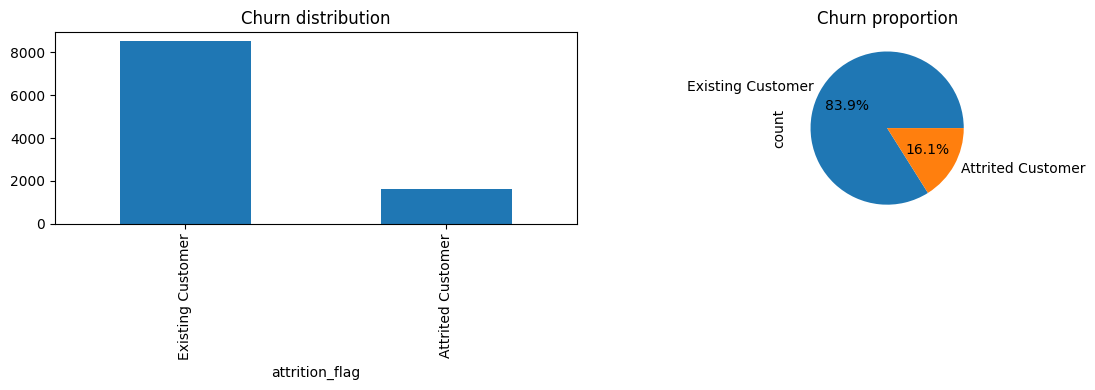

In [7]:
# Churn distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['attrition_flag'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Churn distribution')
df['attrition_flag'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
ax[1].set_title('Churn proportion')
plt.tight_layout()
plt.show()

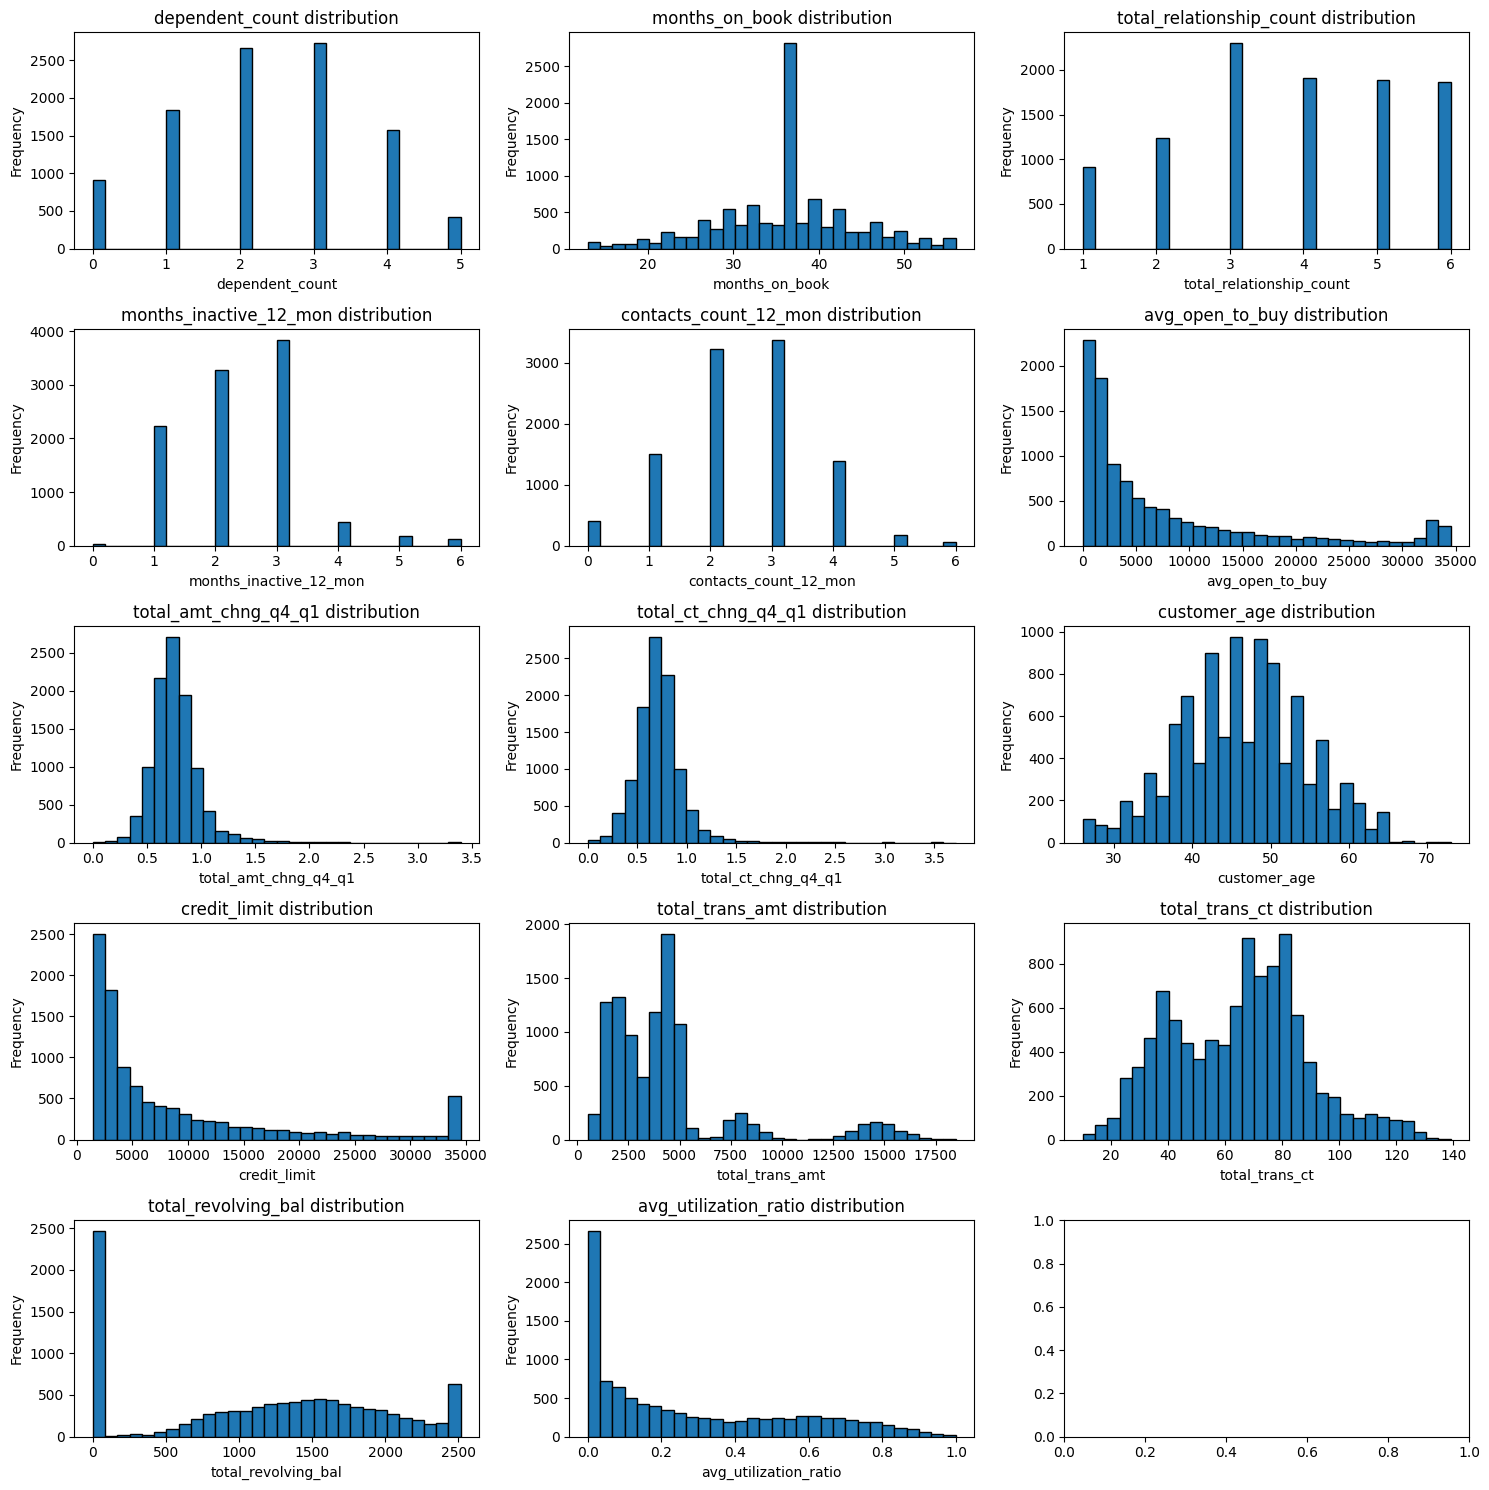

In [8]:
# Numerical variables distribution
numerical_cols = ['dependent_count','months_on_book','total_relationship_count','months_inactive_12_mon',
                  'contacts_count_12_mon','avg_open_to_buy','total_amt_chng_q4_q1','total_ct_chng_q4_q1',
                  'customer_age', 'credit_limit', 'total_trans_amt', 
                  'total_trans_ct', 'total_revolving_bal', 'avg_utilization_ratio']

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

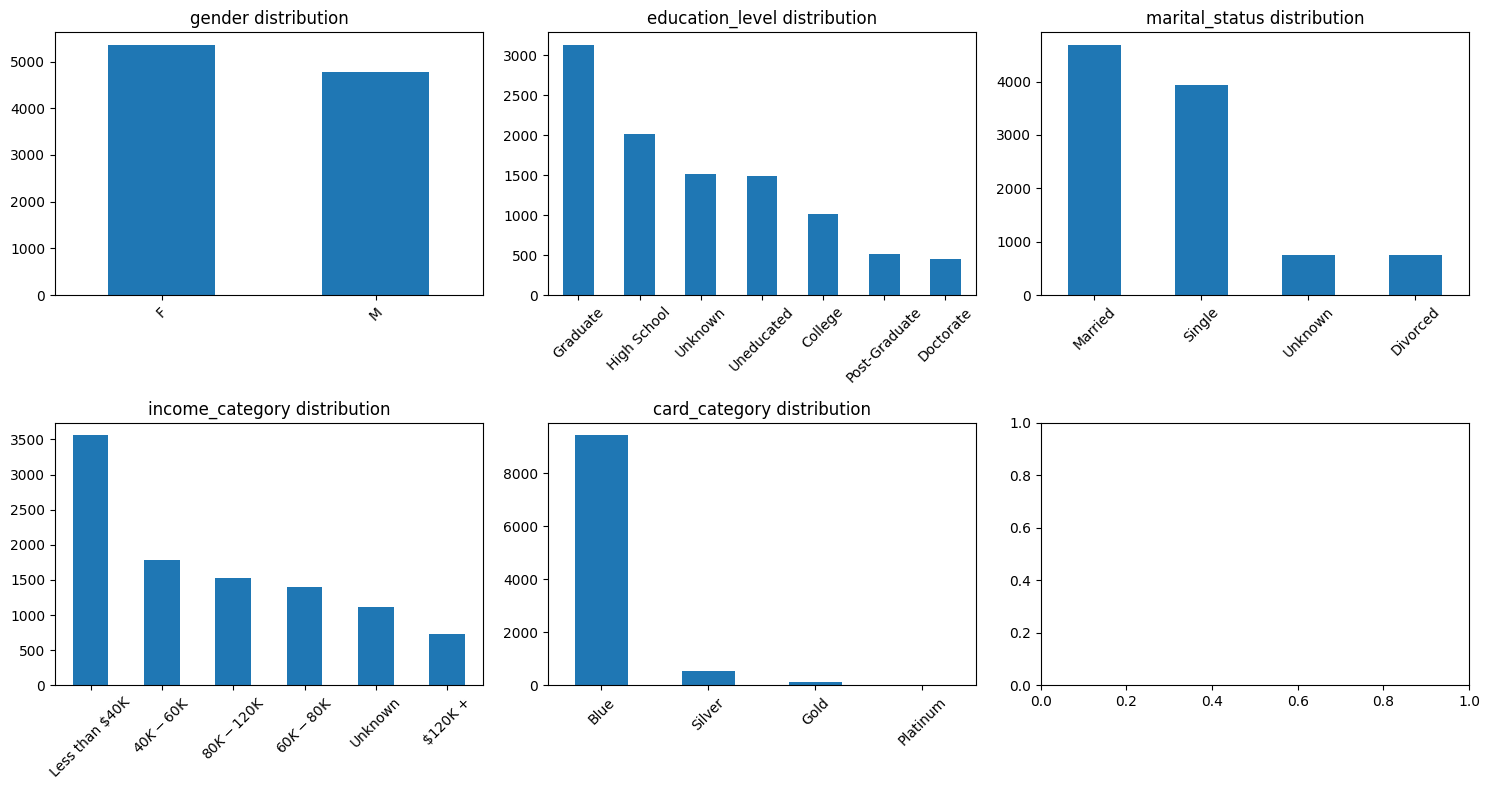

In [9]:
# Categorical variables distribution
categorical_cols = ['gender', 'education_level', 'marital_status', 
                    'income_category', 'card_category']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

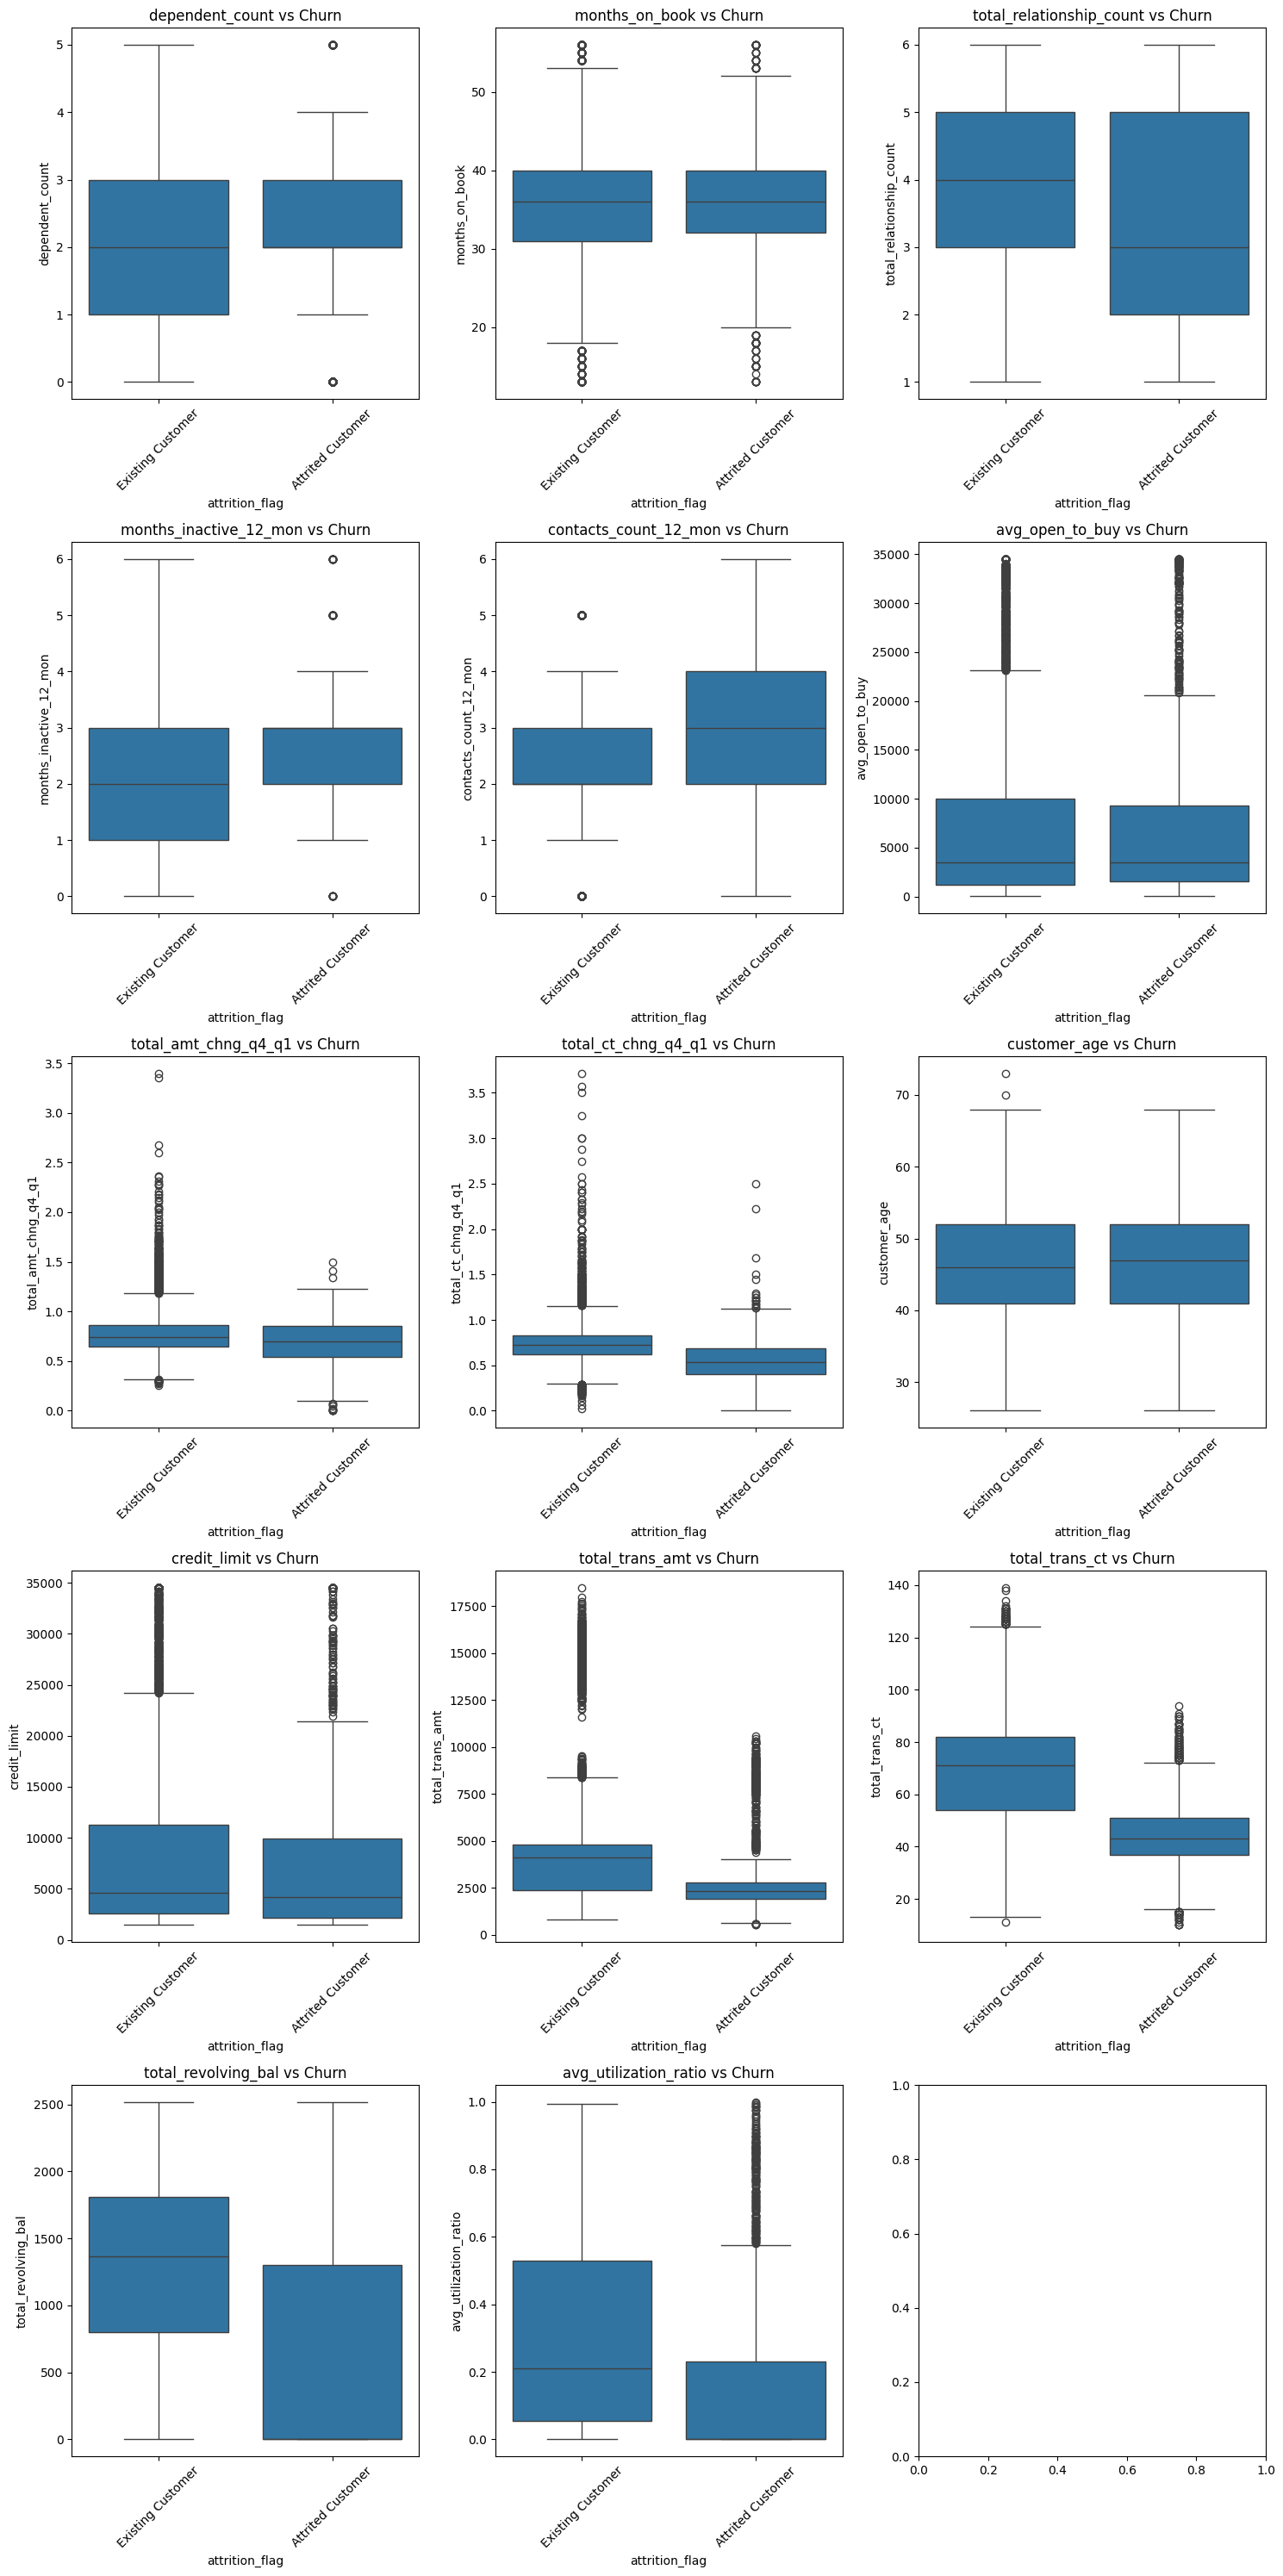


dependent_count:
                    count      mean       std  min  25%  50%  75%  max
attrition_flag                                                        
Attrited Customer  1627.0  2.402581  1.275010  0.0  2.0  2.0  3.0  5.0
Existing Customer  8500.0  2.335412  1.303229  0.0  1.0  2.0  3.0  5.0

months_on_book:
                    count       mean       std   min   25%   50%   75%   max
attrition_flag                                                              
Attrited Customer  1627.0  36.178242  7.796548  13.0  32.0  36.0  40.0  56.0
Existing Customer  8500.0  35.880588  8.021810  13.0  31.0  36.0  40.0  56.0

total_relationship_count:
                    count      mean       std  min  25%  50%  75%  max
attrition_flag                                                        
Attrited Customer  1627.0  3.279656  1.577782  1.0  2.0  3.0  5.0  6.0
Existing Customer  8500.0  3.914588  1.528949  1.0  3.0  4.0  5.0  6.0

months_inactive_12_mon:
                    count      mean  

In [10]:
# bivariate analysis - numerical vs Churn
# comparative boxplots
fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='attrition_flag', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Estadísticas por grupo
for col in numerical_cols:
    print(f"\n{col}:")
    print(df.groupby('attrition_flag')[col].describe())

In [14]:
# bivariate analysis - numerical vs Churn
# comparative boxplots

for col in numerical_cols:
    fig = px.box(
        df,
        x='attrition_flag',
        y=col,
        color='attrition_flag',
        points='outliers',  # 'all' -- id for show all, 'outliers' is only "no typical" values.
        title=f'{col} vs Churn',
        hover_data=['clientnum']
    )
    fig.update_layout(
        xaxis_title="Client status",
        yaxis_title=col,
        legend_title="Churn",
        width=600,
        height=400
    )
    fig.show()
    
    # optional: show statistics
    print(f"\nEstadísticas de {col}:")
    print(df.groupby('attrition_flag')[col].describe().round(2))
    print("-"*50)


Estadísticas de dependent_count:
                    count  mean   std  min  25%  50%  75%  max
attrition_flag                                                
Attrited Customer  1627.0  2.40  1.28  0.0  2.0  2.0  3.0  5.0
Existing Customer  8500.0  2.34  1.30  0.0  1.0  2.0  3.0  5.0
--------------------------------------------------



Estadísticas de months_on_book:
                    count   mean   std   min   25%   50%   75%   max
attrition_flag                                                      
Attrited Customer  1627.0  36.18  7.80  13.0  32.0  36.0  40.0  56.0
Existing Customer  8500.0  35.88  8.02  13.0  31.0  36.0  40.0  56.0
--------------------------------------------------



Estadísticas de total_relationship_count:
                    count  mean   std  min  25%  50%  75%  max
attrition_flag                                                
Attrited Customer  1627.0  3.28  1.58  1.0  2.0  3.0  5.0  6.0
Existing Customer  8500.0  3.91  1.53  1.0  3.0  4.0  5.0  6.0
--------------------------------------------------



Estadísticas de months_inactive_12_mon:
                    count  mean   std  min  25%  50%  75%  max
attrition_flag                                                
Attrited Customer  1627.0  2.69  0.90  0.0  2.0  3.0  3.0  6.0
Existing Customer  8500.0  2.27  1.02  0.0  1.0  2.0  3.0  6.0
--------------------------------------------------



Estadísticas de contacts_count_12_mon:
                    count  mean   std  min  25%  50%  75%  max
attrition_flag                                                
Attrited Customer  1627.0  2.97  1.09  0.0  2.0  3.0  4.0  6.0
Existing Customer  8500.0  2.36  1.08  0.0  2.0  2.0  3.0  5.0
--------------------------------------------------


...


Estadísticas de credit_limit:
                    count     mean      std     min     25%     50%       75%  \
attrition_flag                                                                  
Attrited Customer  1627.0  8136.04  9095.33  1438.3  2114.0  4178.0   9933.50   
Existing Customer  8500.0  8726.88  9084.97  1438.3  2602.0  4643.5  11252.75   

                       max  
attrition_flag              
Attrited Customer  34516.0  
Existing Customer  34516.0  
--------------------------------------------------



Estadísticas de total_trans_amt:
                    count     mean      std    min      25%     50%      75%  \
attrition_flag                                                                 
Attrited Customer  1627.0  3095.03  2308.23  510.0  1903.50  2329.0  2772.00   
Existing Customer  8500.0  4654.66  3512.77  816.0  2384.75  4100.0  4781.25   

                       max  
attrition_flag              
Attrited Customer  10583.0  
Existing Customer  18484.0  
--------------------------------------------------



Estadísticas de total_trans_ct:
                    count   mean    std   min   25%   50%   75%    max
attrition_flag                                                        
Attrited Customer  1627.0  44.93  14.57  10.0  37.0  43.0  51.0   94.0
Existing Customer  8500.0  68.67  22.92  11.0  54.0  71.0  82.0  139.0
--------------------------------------------------



Estadísticas de total_revolving_bal:
                    count     mean     std  min    25%     50%     75%     max
attrition_flag                                                                
Attrited Customer  1627.0   672.82  921.39  0.0    0.0     0.0  1303.5  2517.0
Existing Customer  8500.0  1256.60  757.75  0.0  800.0  1364.0  1807.0  2517.0
--------------------------------------------------



Estadísticas de avg_utilization_ratio:
                    count  mean   std  min   25%   50%   75%   max
attrition_flag                                                    
Attrited Customer  1627.0  0.16  0.26  0.0  0.00  0.00  0.23  1.00
Existing Customer  8500.0  0.30  0.27  0.0  0.06  0.21  0.53  0.99
--------------------------------------------------


In [15]:
# bivariate analysis - categorical vs Churn
# Clustered bar charts
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['attrition_flag'])
    
    fig = px.bar(
        ct,
        barmode='group',
        title=f'{col} vs Churn',
        labels={'value': 'Cantidad', 'variable': 'Estado'}
    )
    fig.update_layout(
        xaxis_title=col,
        yaxis_title='Clients',
        width=600,
        height=400
    )
    fig.show()
    
    # Churn rate by category
    ct_percent = pd.crosstab(df[col], df['attrition_flag'], normalize='index') * 100
    
    fig = px.bar(
        x=ct_percent.index,
        y=ct_percent['Attrited Customer'] if 'Attrited Customer' in ct_percent.columns else [],
        title=f'Churn rate (%) by {col}',
        labels={'x': col, 'y': 'Churn rate (%)'},
        text_auto='.1f'
    )
    fig.update_layout(width=600, height=400)
    fig.show()

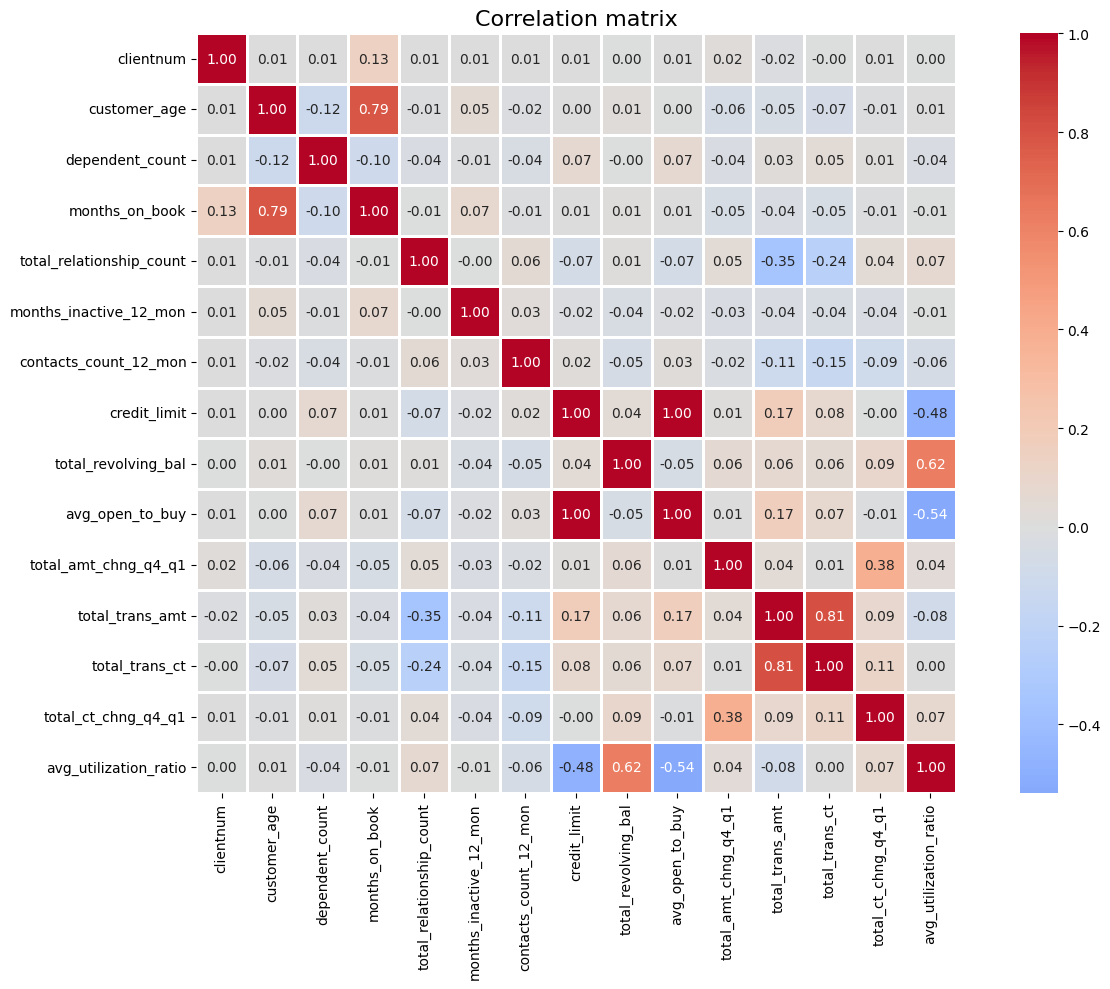


Top correlations with total_trans_amt:
total_trans_amt           1.000000
total_trans_ct            0.807192
credit_limit              0.171730
avg_open_to_buy           0.165923
total_ct_chng_q4_q1       0.085581
total_revolving_bal       0.064370
total_amt_chng_q4_q1      0.039678
dependent_count           0.025046
clientnum                -0.019692
months_inactive_12_mon   -0.036982
Name: total_trans_amt, dtype: float64


In [16]:
# Select only numerical variables
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
plt.figure(figsize=(14, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Top correlations with important variables
print("\nTop correlations with total_trans_amt:")
print(correlation_matrix['total_trans_amt'].sort_values(ascending=False).head(10))

In [17]:
# Drop useless and high correlation variables
columns_to_drop = ['clientnum', 'credit_limit', 
                   'total_trans_amt', 'total_amt_chng_q4_q1', 'total_revolving_bal']

df = df.drop(columns=columns_to_drop)

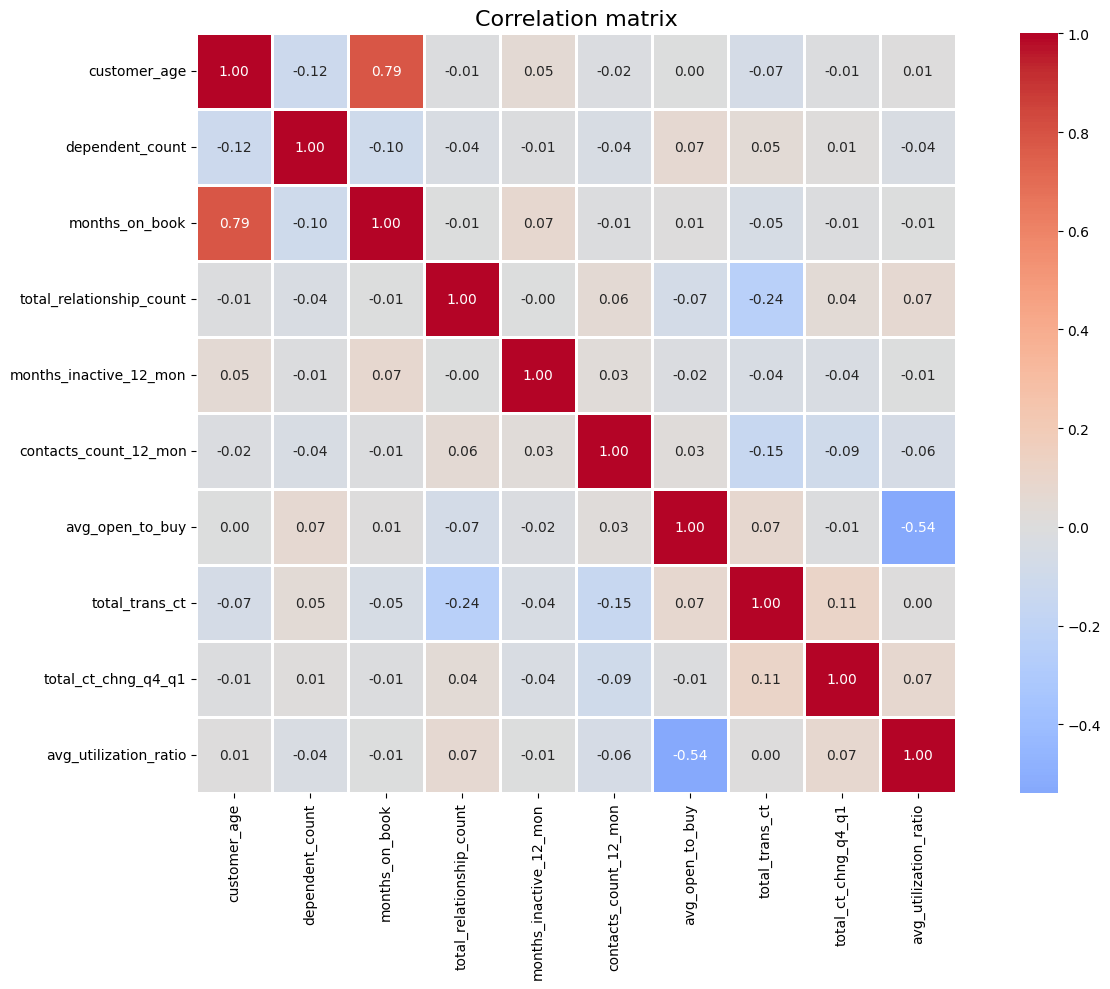

In [18]:
# Select only numerical variables
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
plt.figure(figsize=(14, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation matrix', fontsize=16)
plt.tight_layout()
plt.show()